# CGS698C — Assignment 05

In [ ]:
install.packages(c("brms", "tidyverse"), repos="https://cloud.r-project.org")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘numDeriv’, ‘plyr’, ‘StanHeaders’, ‘inline’, ‘gridExtra’, ‘RcppParallel’, ‘QuickJSR’, ‘RcppEigen’, ‘BH’, ‘checkmate’, ‘tensorA’, ‘distributional’, ‘ggridges’, ‘reshape2’, ‘mvtnorm’, ‘Brobdingnag’, ‘globals’, ‘listenv’, ‘parallelly’, ‘rstan’, ‘loo’, ‘posterior’, ‘rstantools’, ‘bayesplot’, ‘bridgesampling’, ‘future’, ‘future.apply’, ‘matrixStats’, ‘nleqslv’, ‘coda’, ‘abind’




In [ ]:
library(brms)
library(tidyverse)

Loading required package: Rcpp

Loading 'brms' package (version 2.23.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:stats’:

    ar


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Part 1: Power Posing and Testosterone

In [ ]:
df_powerpose <- read.table("df_powerpose.csv", header=T, sep=",")
head(df_powerpose)

,X,id,hptreat,female,age,testm1,testm2
,<int>,<int>,<chr>,<chr>,<int>,<dbl>,<dbl>
1,2,29,High,Male,19,38.725,62.375
2,3,30,Low,Female,20,32.770,29.235
3,4,31,High,Female,20,32.320,27.510
4,5,32,Low,Female,18,17.995,28.655
5,7,34,Low,Female,21,73.580,44.670
6,8,35,High,Female,20,80.695,105.485


In [ ]:
df_powerpose$delta_test <- df_powerpose$testm2 - df_powerpose$testm1
df_powerpose$hptreat    <- factor(df_powerpose$hptreat, levels = c("Low", "High"))

We model the change in testosterone (`testm2 - testm1`) as the outcome. Salivary testosterone typically ranges 10–150 pg/ml, so `Normal(0, 20)` is a weakly informative prior — it allows large effects while not placing mass on implausible values.

In [ ]:
fit_pose <- brm(
  delta_test ~ 1 + hptreat,
  data   = df_powerpose,
  family = gaussian(),
  prior  = c(
    prior(normal(0, 20), class = Intercept),
    prior(normal(0, 20), class = b)
  ),
  chains = 4, iter = 2000, warmup = 1000, cores = 4, seed = 42
)
summary(fit_pose)

Compiling Stan program...

Start sampling



 Family: gaussian 
  Links: mu = identity 
Formula: delta_test ~ 1 + hptreat 
   Data: df_powerpose (Number of observations: 39) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
            Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept      -3.88      4.52   -12.77     5.26 1.00     3844     2624
hptreatHigh     7.87      6.26    -4.26    19.97 1.00     3690     2664

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma    20.48      2.43    16.38    25.92 1.00     3772     2749

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

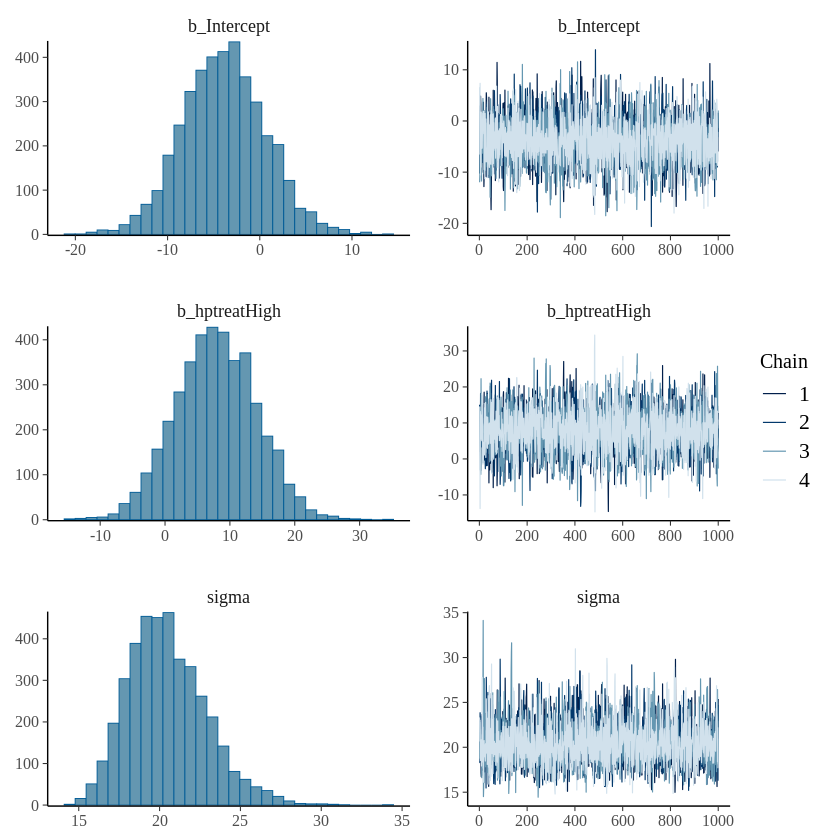

In [ ]:
plot(fit_pose)

In [ ]:
post <- as_draws_df(fit_pose)
mean(post$b_hptreatHigh > 0)

[1] 0.895

`b_hptreatHigh` is the estimated difference in testosterone change between High and Low pose groups. `P(b > 0)` is the posterior probability that high posing increases testosterone relative to low posing.

## Part 2: Poisson Regression — Crossing Dependencies
### Exercise 2.1

In [ ]:
crossing_model <- function(sentence_length, alpha, beta) {
  lambda <- exp(alpha + beta * sentence_length)
  rpois(1, lambda = lambda)
}

set.seed(42)
crossing_model(sentence_length = 10, alpha = 0.15, beta = 0.25)

[1] 19

### Exercise 2.2

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000   3.000   3.305   4.000  14.000 

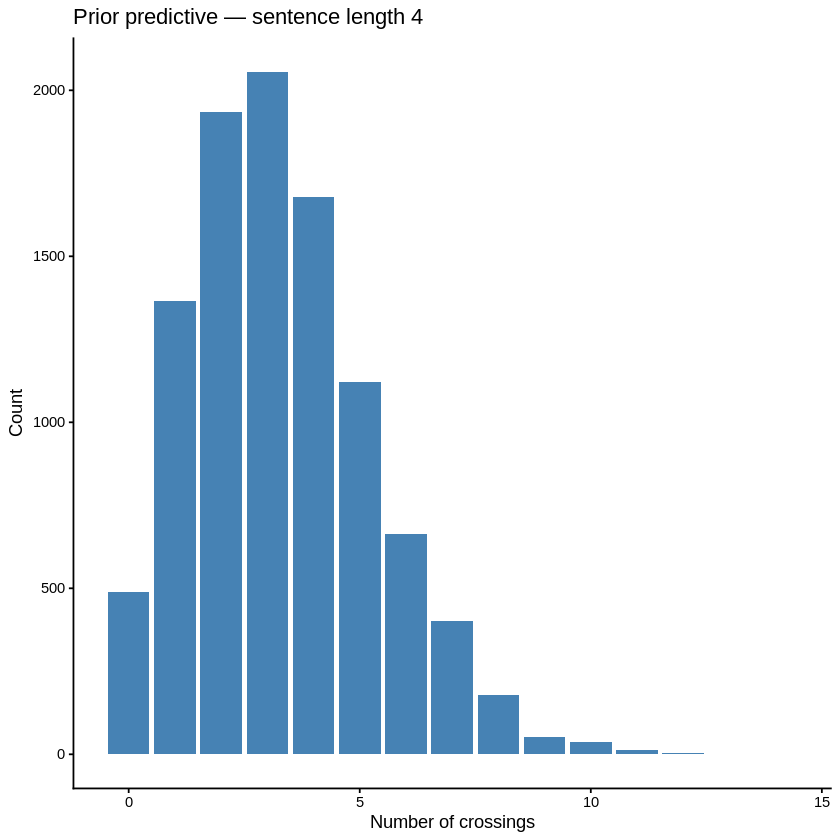

In [ ]:
set.seed(123)
N <- 10000

sample_truncnorm <- function(n, mu, sigma) {
  s <- rnorm(n * 5, mu, sigma)
  s[s >= 0][1:n]
}

alpha_draws <- sample_truncnorm(N, 0.15, 0.1)
beta_draws  <- sample_truncnorm(N, 0.25, 0.05)

prior_pred <- rpois(N, lambda = exp(alpha_draws + beta_draws * 4))
summary(prior_pred)

ggplot(data.frame(x = prior_pred), aes(x = x)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Prior predictive — sentence length 4",
       x = "Number of crossings", y = "Count") +
  theme_classic()

### Exercise 2.3

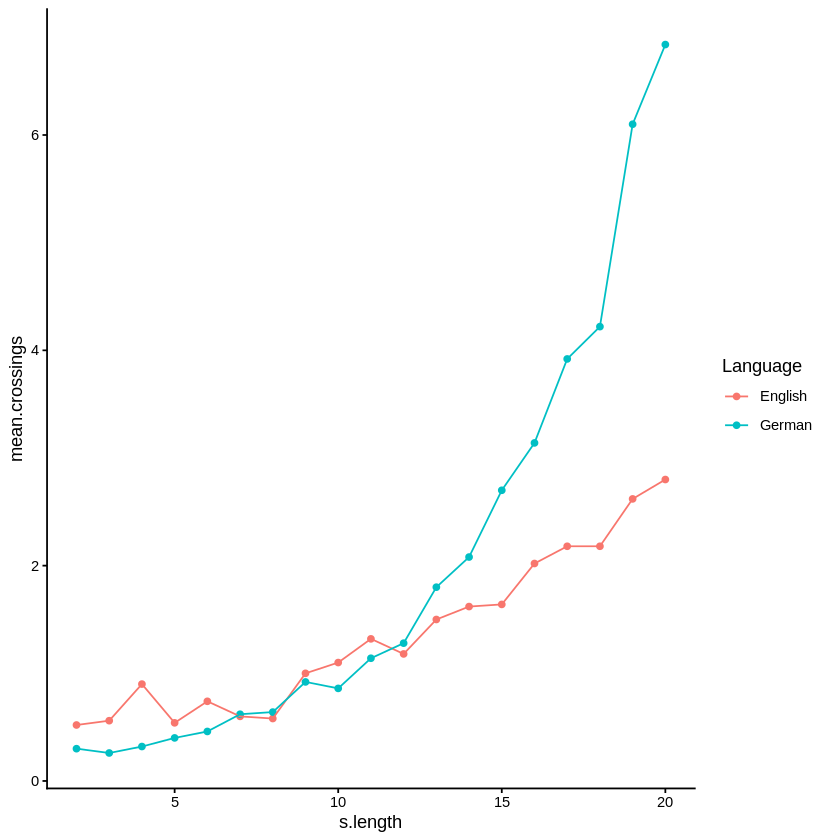

In [ ]:
observed <- read.table("crossings.csv", sep=",", header=T)

observed %>%
  group_by(Language, s.length) %>%
  summarise(mean.crossings = mean(nCross), .groups = "drop") %>%
  ggplot(aes(x = s.length, y = mean.crossings, group = Language, color = Language)) +
  geom_point() + geom_line() +
  theme_classic()

In [ ]:
observed$s.length <- observed$s.length - mean(observed$s.length)
observed$lang     <- ifelse(observed$Language == "German", 1, 0)

In [ ]:
fit_m1 <- brm(
  nCross ~ 1 + s.length,
  data   = observed,
  family = poisson(link = "log"),
  prior  = c(
    prior(normal(0.15, 0.1), class = Intercept),
    prior(normal(0, 0.15),   class = b)
  ),
  chains = 4, iter = 2000, warmup = 1000, cores = 4, seed = 42
)
summary(fit_m1)

Compiling Stan program...

Start sampling



 Family: poisson 
  Links: mu = log 
Formula: nCross ~ 1 + s.length 
   Data: observed (Number of observations: 1900) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept     0.20      0.02     0.15     0.24 1.00     1165     1708
s.length      0.15      0.00     0.14     0.16 1.00     1488     1964

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

In [ ]:
fit_m2 <- brm(
  nCross ~ 1 + s.length + lang + s.length:lang,
  data   = observed,
  family = poisson(link = "log"),
  prior  = c(
    prior(normal(0.15, 0.1), class = Intercept),
    prior(normal(0, 0.15),   class = b)
  ),
  chains = 4, iter = 2000, warmup = 1000, cores = 4, seed = 42
)
summary(fit_m2)

Compiling Stan program...

Start sampling



 Family: poisson 
  Links: mu = log 
Formula: nCross ~ 1 + s.length + lang + s.length:lang 
   Data: observed (Number of observations: 1900) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept         0.16      0.03     0.10     0.22 1.00     2283     2185
s.length          0.10      0.01     0.09     0.11 1.00     1978     2154
lang              0.03      0.05    -0.06     0.12 1.00     2067     2075
s.length:lang     0.10      0.01     0.08     0.11 1.00     1603     1946

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

### Exercise 2.4 — 5-Fold Cross-Validation

In [ ]:
set.seed(42)

lpds_m1  <- c()
lpds_m2  <- c()
untested <- observed

for (k in 1:5) {
  ytest    <- sample_n(untested, size = nrow(observed) / 5)
  ytrain   <- setdiff(observed, ytest)
  untested <- setdiff(untested, ytest)

  fold_m1 <- brm(
    nCross ~ 1 + s.length, data = ytrain,
    family = poisson(link = "log"),
    prior  = c(prior(normal(0.15, 0.1), class = Intercept),
               prior(normal(0, 0.15),   class = b)),
    chains = 4, cores = 4, seed = k, refresh = 0
  )

  fold_m2 <- brm(
    nCross ~ 1 + s.length + lang + s.length:lang, data = ytrain,
    family = poisson(link = "log"),
    prior  = c(prior(normal(0.15, 0.1), class = Intercept),
               prior(normal(0, 0.15),   class = b)),
    chains = 4, cores = 4, seed = k, refresh = 0
  )

  post_m1 <- as_draws_df(fold_m1)
  post_m2 <- as_draws_df(fold_m2)

  lppd_m1 <- 0
  lppd_m2 <- 0

  for (i in 1:nrow(ytest)) {
    lppd_m1 <- lppd_m1 + log(mean(
      dpois(ytest[i,]$nCross,
            lambda = exp(post_m1$b_Intercept +
                         post_m1$b_s.length * ytest[i,]$s.length))
    ))

    lppd_m2 <- lppd_m2 + log(mean(
      dpois(ytest[i,]$nCross,
            lambda = exp(post_m2$b_Intercept +
                         post_m2$b_s.length * ytest[i,]$s.length +
                         post_m2$b_lang     * ytest[i,]$lang +
                         post_m2[["b_s.length:lang"]] * ytest[i,]$s.length * ytest[i,]$lang))
    ))
  }

  lpds_m1 <- c(lpds_m1, lppd_m1)
  lpds_m2 <- c(lpds_m2, lppd_m2)
  cat("Fold", k, "| M1:", round(lppd_m1, 2), "M2:", round(lppd_m2, 2), "\n")
}

Compiling Stan program...

Start sampling

Compiling Stan program...

Start sampling



Fold 1 | M1: -548.66 M2: -521.62 


Compiling Stan program...

Start sampling

Compiling Stan program...

Start sampling



Fold 2 | M1: -571.37 M2: -544.46 


Compiling Stan program...

Start sampling

Compiling Stan program...

Start sampling



Fold 3 | M1: -553.85 M2: -524.59 


Compiling Stan program...

Start sampling

Compiling Stan program...

Start sampling



Fold 4 | M1: -572.89 M2: -539.41 


Compiling Stan program...

Start sampling

Compiling Stan program...

Start sampling



Fold 5 | M1: -568.31 M2: -550.95 


In [ ]:
elpd_m1   <- sum(lpds_m1)
elpd_m2   <- sum(lpds_m2)
diff_elpd <- elpd_m2 - elpd_m1

cat("ELPD M1:", round(elpd_m1, 2), "\n")
cat("ELPD M2:", round(elpd_m2, 2), "\n")
cat("Difference (M2 - M1):", round(diff_elpd, 2), "\n")

ELPD M1: -2815.08 
ELPD M2: -2681.03 
Difference (M2 - M1): 134.05 


A positive difference favours M2 — the interaction with language improves out-of-sample predictions. A negative or near-zero value means M1 is sufficient.